# BirdCLEF+ 2026 — Exploratory Data Analysis

This notebook explores the dataset from the CSVs before touching any audio files.
Key questions to answer here that will drive preprocessing decisions:

1. How many species / classes are there, and how skewed is the distribution?
2. What is the recording quality distribution (ratings)?
3. What is the typical audio duration — how many clips are shorter than 5 s?
4. Where are the recordings from geographically?
5. What does the labeled soundscapes subset look like?
6. Which species appear **only** in `train_soundscapes` and not in `train_audio`?

**Data root**: set `DATA_ROOT` to the SwitchDrive mount path.

In [1]:
from pathlib import Path
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# ---------- adjust this to the SwitchDrive mount path ----------
# DATA_ROOT = Path(os.environ.get("DATA_ROOT", "/home/user/data"))
DATA_ROOT = Path('/tmp/birdclef-2026')

# ---------------------------------------------------------------

assert DATA_ROOT.exists(), f"DATA_ROOT not found: {DATA_ROOT}"
print("Data root:", DATA_ROOT)

Matplotlib is building the font cache; this may take a moment.


Data root: /tmp/birdclef-2026


## 1. Load metadata CSVs

In [2]:
train = pd.read_csv(DATA_ROOT / "train.csv")
taxonomy = pd.read_csv(DATA_ROOT / "taxonomy.csv")
soundscape_labels = pd.read_csv(DATA_ROOT / "train_soundscapes_labels.csv")
sample_sub = pd.read_csv(DATA_ROOT / "sample_submission.csv", nrows=5)

print(f"train.csv            : {len(train):,} rows  ×  {train.shape[1]} cols")
print(f"taxonomy.csv         : {len(taxonomy):,} rows  ×  {taxonomy.shape[1]} cols")
print(f"soundscape_labels.csv: {len(soundscape_labels):,} rows  ×  {soundscape_labels.shape[1]} cols")
print(f"\ntrain.csv columns:\n", train.columns.tolist())
print(f"\ntaxonomy.csv columns:\n", taxonomy.columns.tolist())

train.csv            : 35,549 rows  ×  15 cols
taxonomy.csv         : 234 rows  ×  5 cols
soundscape_labels.csv: 1,478 rows  ×  4 cols

train.csv columns:
 ['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection']

taxonomy.csv columns:
 ['primary_label', 'inat_taxon_id', 'scientific_name', 'common_name', 'class_name']


In [3]:
train.head(3)

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat


In [4]:
taxonomy.head(5)

,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
4,1595929,1595929,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia


## 2. Class inventory

The submission requires predictions for **234 species** (columns from `sample_submission.csv`).
Check how many of those appear in `train_audio` vs. only in `train_soundscapes`.

In [5]:
# Species defined by the submission format
submission_species = [c for c in pd.read_csv(DATA_ROOT / "sample_submission.csv", nrows=0).columns if c != "row_id"]
print(f"Submission species count: {len(submission_species)}")

# Taxonomy breakdown by class
print("\nSpecies by taxonomic class:")
print(taxonomy["class_name"].value_counts().to_string())

Submission species count: 234

Species by taxonomic class:
class_name
Aves        162
Amphibia     35
Insecta      28
Mammalia      8
Reptilia      1


In [7]:
# Which submission species appear in train_audio?
train_audio_species = set(train["primary_label"].unique())

# Which submission species appear in labeled soundscapes?
soundscape_species_raw = soundscape_labels["primary_label"].str.split(";").explode().str.strip()
soundscape_species = set(soundscape_species_raw.unique())

sub_set = set(submission_species)
only_in_soundscapes = sub_set & soundscape_species - train_audio_species
only_in_train_audio = sub_set & train_audio_species - soundscape_species
in_both = sub_set & train_audio_species & soundscape_species
in_neither = sub_set - train_audio_species - soundscape_species

print(f"In train_audio only       : {len(only_in_train_audio)}")
print(f"In soundscapes only       : {len(only_in_soundscapes)}")
print(f"In both                   : {len(in_both)}")
print(f"In neither (no training!) : {len(in_neither)}")

if only_in_soundscapes:
    print(f"\n⚠ Species only in soundscapes (important for dataset design):")
    print(sorted(only_in_soundscapes))

In train_audio only       : 159
In soundscapes only       : 28
In both                   : 47
In neither (no training!) : 0

⚠ Species only in soundscapes (important for dataset design):
['1491113', '25073', '47158son01', '47158son02', '47158son03', '47158son04', '47158son05', '47158son06', '47158son07', '47158son08', '47158son09', '47158son10', '47158son11', '47158son12', '47158son13', '47158son14', '47158son15', '47158son16', '47158son17', '47158son18', '47158son19', '47158son20', '47158son21', '47158son22', '47158son23', '47158son24', '47158son25', '517063']


Those 28 extra species in the soundscapes are likely background or incidental species that were annotated in the real-world recordings but don't have corresponding clean training audio in train.csv. They could be:

- Species outside the competition's official taxonomy
- Species present in the Pantanal but not part of the target classification task
- Annotation noise or broader taxonomic labels used in soundscape labeling

This is actually a deliberate competition design choice — the model is only evaluated on the 206 species with sufficient clean training data. The soundscapes serve as additional training signal for those same 206 species in real-world acoustic conditions, not as a source of new classes. So, we will ignore these extra 28 classes.

## 3. Class distribution in `train_audio`

In [6]:
counts = train["primary_label"].value_counts()
classes = train["primary_label"].nunique()

print(f"Total recordings in train_audio : {len(train):,}")
print(f"Unique primary_label species    : {classes}")
print(f"\nTop 10 species by recording count:")
print(counts.head(10))
print(f"\nBottom 10 species:")
print(counts.tail(10))

Total recordings in train_audio : 35,549
Unique primary_label species    : 206

Top 10 species by recording count:
primary_label
rubthr1    499
banana     498
fepowl     497
soulap1    497
houspa     496
coffal1    495
osprey     495
socfly1    494
compau     493
yeofly1    493
Name: count, dtype: int64

Bottom 10 species:
primary_label
64898      3
74580      3
sptnig1    3
209233     2
24321      2
70711      2
116570     1
23150      1
23724      1
516975     1
Name: count, dtype: int64


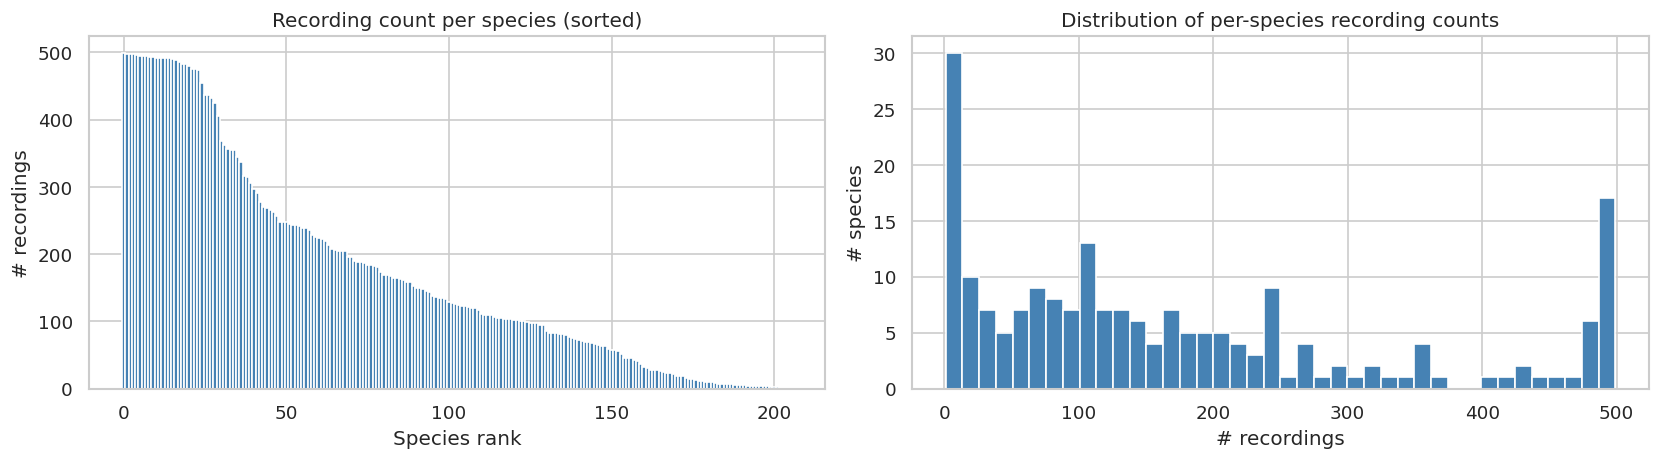


Species remaining after min-recordings threshold:
  >=  50 recordings: 154 species  (75%)
  >= 100 recordings: 124 species  (60%)
  >= 150 recordings: 91 species  (44%)
  >= 200 recordings: 69 species  (33%)
  >= 300 recordings: 40 species  (19%)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full sorted distribution
axes[0].bar(range(len(counts)), counts.values, width=1.0, color="steelblue")
axes[0].set_xlabel("Species rank")
axes[0].set_ylabel("# recordings")
axes[0].set_title("Recording count per species (sorted)")

# Histogram of per-species counts
axes[1].hist(counts.values, bins=40, color="steelblue", edgecolor="white")
axes[1].set_xlabel("# recordings")
axes[1].set_ylabel("# species")
axes[1].set_title("Distribution of per-species recording counts")

plt.tight_layout()
plt.show()

# Threshold analysis: how many species survive a min-count filter?
thresholds = [50, 100, 150, 200, 300]
print("\nSpecies remaining after min-recordings threshold:")
for t in thresholds:
    surviving = (counts >= t).sum()
    print(f"  >= {t:3d} recordings: {surviving} species  ({surviving/len(counts)*100:.0f}%)")

## 4. Recording quality (ratings)

Rating value counts (0 = no rating, 1-5 scale):
rating
0.0    12849
0.5       22
1.0      147
1.5      120
2.0      598
2.5      518
3.0     2738
3.5     1509
4.0     8018
4.5     2185
5.0     6845
Name: count, dtype: int64


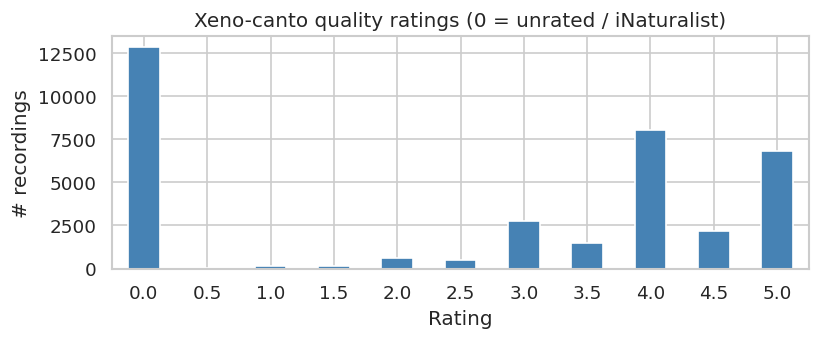


Collection (XC = Xeno-canto, iNat = iNaturalist):
collection
XC      23043
iNat    12506
Name: count, dtype: int64


In [10]:
print("Rating value counts (0 = no rating, 1-5 scale):")
print(train["rating"].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(7, 3))
train["rating"].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue", rot=0)
ax.set_xlabel("Rating")
ax.set_ylabel("# recordings")
ax.set_title("Xeno-canto quality ratings (0 = unrated / iNaturalist)")
plt.tight_layout()
plt.show()

# Collection breakdown
print("\nCollection (XC = Xeno-canto, iNat = iNaturalist):")
print(train["collection"].value_counts())

## 5. Secondary labels

Secondary labels indicate co-occurring species. Understanding their density informs
whether we should use them as soft positive labels during training.

Recordings with secondary labels: 4,372 / 35,549  (12.3%)


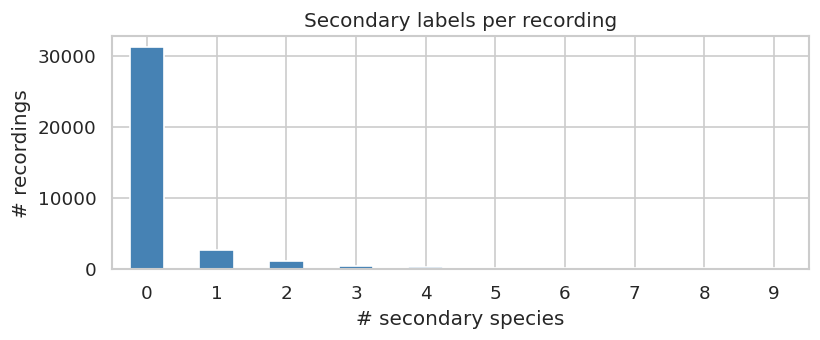

In [11]:
has_secondary = train["secondary_labels"].notna() & (train["secondary_labels"] != "[]")
print(f"Recordings with secondary labels: {has_secondary.sum():,} / {len(train):,}  "
      f"({has_secondary.mean()*100:.1f}%)")

# Distribution of secondary label count per recording
def count_labels(s):
    if pd.isna(s) or s in ("", "[]"):
        return 0
    # Strip brackets and split
    s = s.strip("[] ").replace("'", "")
    return len([x for x in s.split(",") if x.strip()])

train["n_secondary"] = train["secondary_labels"].apply(count_labels)

fig, ax = plt.subplots(figsize=(7, 3))
train["n_secondary"].value_counts().sort_index().head(10).plot(kind="bar", ax=ax, color="steelblue", rot=0)
ax.set_xlabel("# secondary species")
ax.set_ylabel("# recordings")
ax.set_title("Secondary labels per recording")
plt.tight_layout()
plt.show()

## 6. Geographic distribution

Recordings with coordinates: 35,549 / 35,549


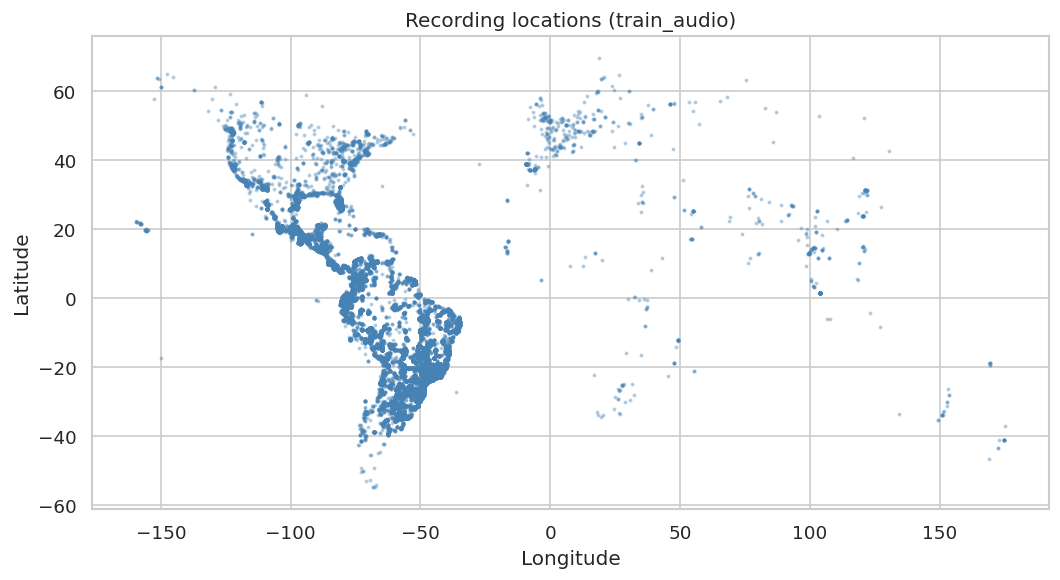


Recordings within approximate Pantanal bbox: 1,347


In [12]:
geo = train.dropna(subset=["latitude", "longitude"])
print(f"Recordings with coordinates: {len(geo):,} / {len(train):,}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(geo["longitude"], geo["latitude"], s=2, alpha=0.3, color="steelblue")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Recording locations (train_audio)")
plt.tight_layout()
plt.show()

# Pantanal bounding box for reference (approx -22 to -14 lat, -58 to -53 lon)
pantanal_lat = (-22, -14)
pantanal_lon = (-58, -53)
in_pantanal = (
    geo["latitude"].between(*pantanal_lat) &
    geo["longitude"].between(*pantanal_lon)
)
print(f"\nRecordings within approximate Pantanal bbox: {in_pantanal.sum():,}")

## 7. Labeled soundscapes (`train_soundscapes_labels.csv`)

These are expert-annotated 5-second segments from the longer soundscape files.
They form a higher-quality supervision signal and may contain species not in `train_audio`.

In [13]:
soundscape_labels.head()

,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380


In [17]:
# How many unique soundscape files?
n_soundscape_files = soundscape_labels["filename"].nunique()
n_segments = len(soundscape_labels)
print(f"Unique soundscape files  : {n_soundscape_files}")
print(f"Labeled 5-second segments: {n_segments:,}")
print(f"Mean segments per file   : {n_segments / n_soundscape_files:.1f}")

# Segment duration check
soundscape_labels["duration"] = pd.to_timedelta(soundscape_labels["end"]) - pd.to_timedelta(soundscape_labels["start"])
print(f"\nSegment duration stats (should all be 5.0 s):")
print(soundscape_labels["duration"].describe())

Unique soundscape files  : 66
Labeled 5-second segments: 1,478
Mean segments per file   : 22.4

Segment duration stats (should all be 5.0 s):
count               1478
mean     0 days 00:00:05
std      0 days 00:00:00
min      0 days 00:00:05
25%      0 days 00:00:05
50%      0 days 00:00:05
75%      0 days 00:00:05
max      0 days 00:00:05
Name: duration, dtype: object


Unique species in labeled soundscapes: 40


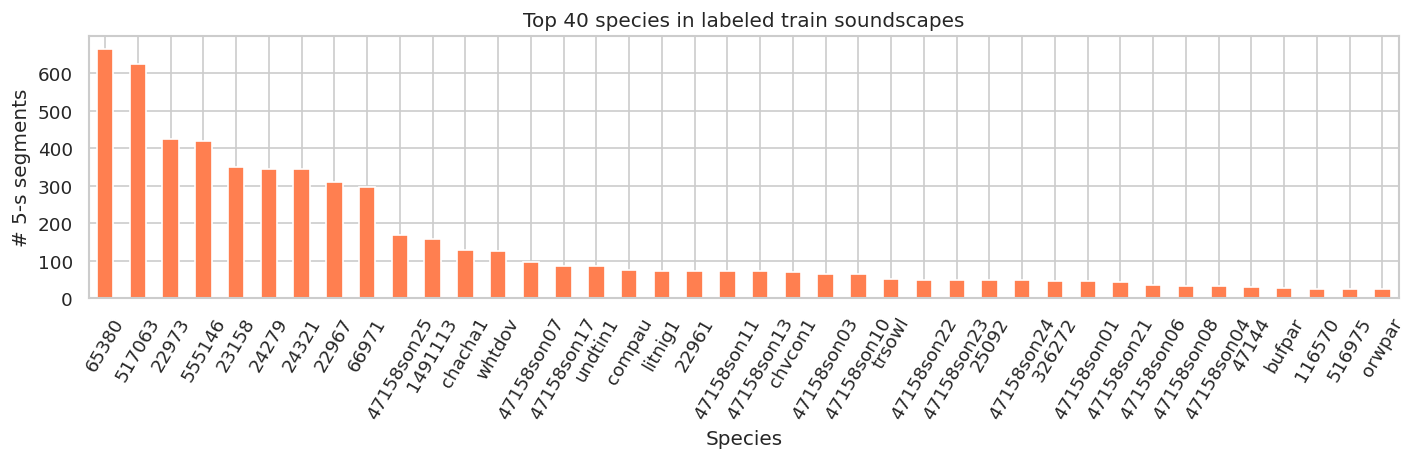

In [18]:
# Species distribution in labeled soundscapes
sc_species_counts = soundscape_species_raw.value_counts()
print(f"Unique species in labeled soundscapes: {sc_species_counts.nunique()}")

fig, ax = plt.subplots(figsize=(12, 4))
sc_species_counts.head(40).plot(kind="bar", ax=ax, color="coral", rot=60)
ax.set_xlabel("Species")
ax.set_ylabel("# 5-s segments")
ax.set_title("Top 40 species in labeled train soundscapes")
plt.tight_layout()
plt.show()

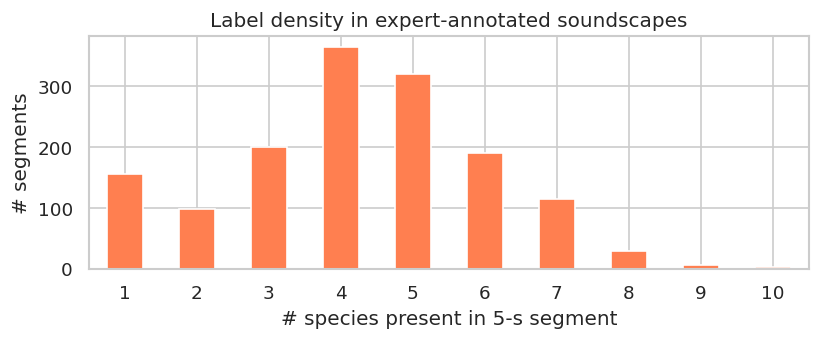

Mean species per segment: 4.22
Max  species per segment: 10


In [19]:
# Multi-label density in soundscapes
n_species_per_segment = soundscape_labels["primary_label"].str.split(";").apply(len)

fig, ax = plt.subplots(figsize=(7, 3))
n_species_per_segment.value_counts().sort_index().plot(kind="bar", ax=ax, color="coral", rot=0)
ax.set_xlabel("# species present in 5-s segment")
ax.set_ylabel("# segments")
ax.set_title("Label density in expert-annotated soundscapes")
plt.tight_layout()
plt.show()

print(f"Mean species per segment: {n_species_per_segment.mean():.2f}")
print(f"Max  species per segment: {n_species_per_segment.max()}")

## 8. Audio duration distribution

**Status: completed.** Duration analysis was run for all 35,549 recordings.
Per-file durations are stored in `data/train_with_duration.csv` and the duration
cache at `.cache/birdclef/train_audio_durations.json`.

**Key finding:** Most recordings are longer than 5 s. Sub-5 s clips are
**zero-padded** to a full 5 s window — no recordings are discarded. Each file
contributes at least one chunk (`max(1, floor(duration / 5))`).

The code cell below is kept for reference; the decisions it informed are in section 10.

Duration cache: 51,258 files
count    51258.00
mean        35.26
std         77.55
min          0.01
25%         10.95
50%         21.19
75%         40.15
max       6881.10
dtype: float64
Fraction shorter than 5s: 7.2%


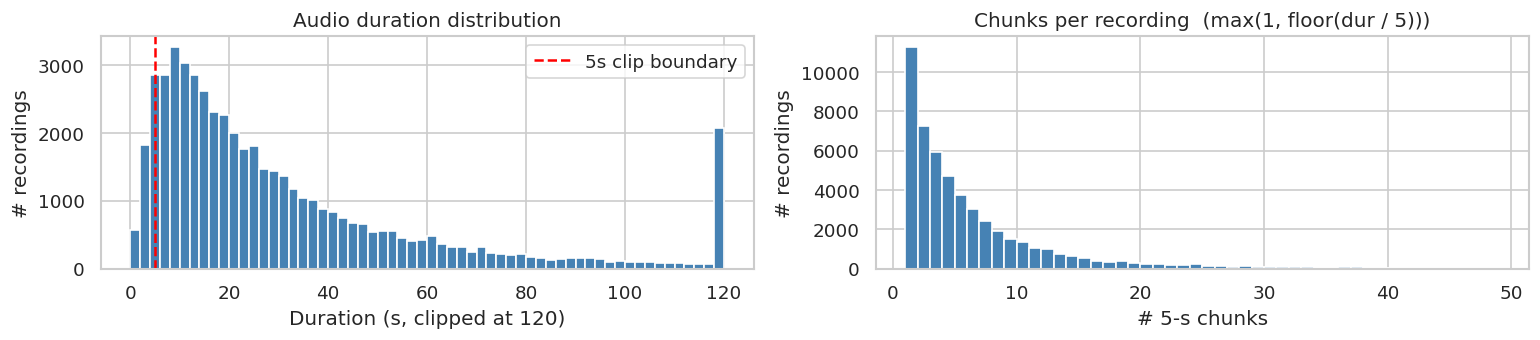

Total chunks: 339,984


In [20]:
import json as _json

CLIP_LEN = 5  # seconds

_cache_path = Path(os.environ.get(
    "BIRDCLEF_DURATION_CACHE",
    str(Path("..") / ".cache" / "birdclef" / "train_audio_durations.json"),
))

with open(_cache_path) as _f:
    _dur_cache = _json.load(_f)

# cache format: {abspath: {"duration": float, "mtime_ns": int, "size": int}}
durations = pd.Series({k: v["duration"] for k, v in _dur_cache.items()})

print(f"Duration cache: {len(durations):,} files")
print(durations.describe().round(2))
print(f"Fraction shorter than {CLIP_LEN}s: {(durations < CLIP_LEN).mean():.1%}")

chunks = durations.apply(lambda d: max(1, int(d // CLIP_LEN)))

fig, axes = plt.subplots(1, 2, figsize=(13, 3))
axes[0].hist(durations.clip(upper=120), bins=60, color="steelblue", edgecolor="white")
axes[0].axvline(CLIP_LEN, color="red", linestyle="--", label=f"{CLIP_LEN}s clip boundary")
axes[0].set_xlabel("Duration (s, clipped at 120)")
axes[0].set_ylabel("# recordings")
axes[0].set_title("Audio duration distribution")
axes[0].legend()
axes[1].hist(chunks, bins=range(1, min(50, int(chunks.max()) + 2)), color="steelblue", edgecolor="white")
axes[1].set_xlabel("# 5-s chunks")
axes[1].set_ylabel("# recordings")
axes[1].set_title("Chunks per recording  (max(1, floor(dur / 5)))")
plt.tight_layout()
plt.show()
print(f"Total chunks: {chunks.sum():,}")

## 9. Sample mel-spectrograms per taxonomic class

**Status: completed.** Mel-spectrogram parameters were validated visually in
`data/preprocessing/preprocessing_check.ipynb`, which loads the production
pipeline and plots training/val/soundscape examples with and without SpecAugment.

Confirmed: `sr=32000, n_fft=1024, hop_length=512, n_mels=128, fmin=50, fmax=14000`.
Shape `(1, 128, 313)` for a 5 s clip. Clear time-frequency patterns for bird calls
observed across all taxonomic groups.

Code cell below kept for reference; the transform logic lives in `data/preprocessing/data_pipeline.py`.

train_audio — recordings: 35549, species: 206
Singleton classes moved to train only: 4 recordings, 4 species
Split — train: 24885 (70%), val: 5332 (15%), test: 5332 (15%)  [seed=42]
Number of classes K: 206
[train] duration cache: 51258 existing entries in /home/renku/work/aml2026-group-10/.cache/birdclef/train_audio_durations.json
[train] duration cache: 51258 total entries  (hits=24885, misses=0)  -> /home/renku/work/aml2026-group-10/.cache/birdclef/train_audio_durations.json
[val] duration cache: 51258 existing entries in /home/renku/work/aml2026-group-10/.cache/birdclef/train_audio_durations.json
[val] duration cache: 51258 total entries  (hits=5332, misses=0)  -> /home/renku/work/aml2026-group-10/.cache/birdclef/train_audio_durations.json
[test] duration cache: 51258 existing entries in /home/renku/work/aml2026-group-10/.cache/birdclef/train_audio_durations.json
[test] duration cache: 51258 total entries  (hits=5332, misses=0)  -> /home/renku/work/aml2026-group-10/.cache/birdclef/

/layers/paketo-buildpacks_pip-install/packages/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
/layers/paketo-buildpacks_pip-install/packages/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/layers/paketo-buildpacks_pip-install/packages/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidget

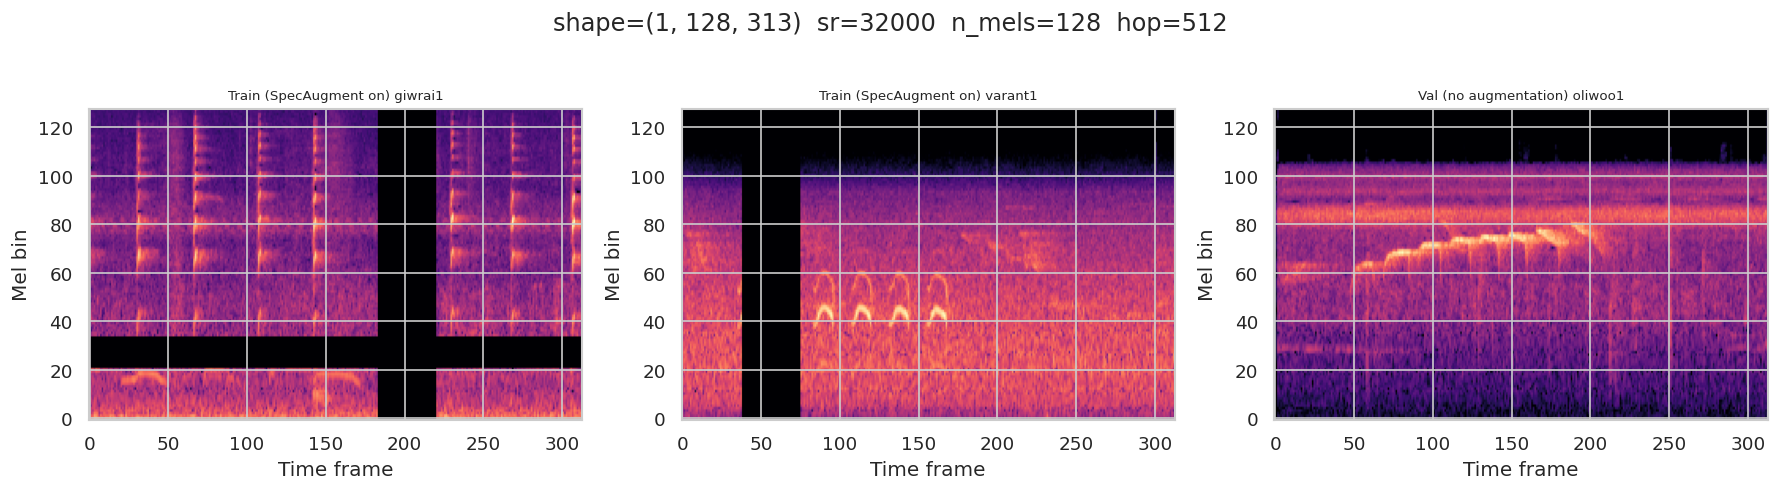

In [21]:
import sys
_repo_root = Path("..").resolve()
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from data.preprocessing.data_pipeline import build_dataloaders

_train_loader, _val_loader, _, mlb = build_dataloaders(
    metadata_csv=str(DATA_ROOT / "train.csv"),
    audio_dir=str(DATA_ROOT / "train_audio"),
    soundscapes_dir=str(DATA_ROOT / "train_soundscapes"),
    soundscapes_csv=str(DATA_ROOT / "train_soundscapes_labels.csv"),
    val_size=0.15, test_size=0.15, batch_size=4, num_workers=0,
)

train_specs, train_labels = next(iter(_train_loader))
val_specs,   val_labels   = next(iter(_val_loader))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, spec, lv, title in [
    (axes[0], train_specs[0], train_labels[0], "Train (SpecAugment on)"),
    (axes[1], train_specs[1], train_labels[1], "Train (SpecAugment on)"),
    (axes[2], val_specs[0],   val_labels[0],   "Val (no augmentation)"),
]:
    active = [mlb.classes_[i] for i in lv.nonzero(as_tuple=True)[0].tolist()][:2]
    ax.imshow(spec.squeeze().numpy(), origin="lower", aspect="auto", cmap="magma")
    ax.set_title(f"{title} {chr(44).join(active) or '(none)'}", fontsize=8)
    ax.set_xlabel("Time frame")
    ax.set_ylabel("Mel bin")
plt.suptitle(
    f"shape={tuple(train_specs[0].shape)}  sr=32000  n_mels=128  hop=512", y=1.02
)
plt.tight_layout()
plt.show()

## 10. Summary: preprocessing decisions

| Question | Finding | Decision |
|---|---|---|
| How many species? | 206 in `train_audio`; 234 in submission | Train on 206; K=69 (>=200 recs) for HP search only |
| Clips < 5 s? | Small minority; most recordings >=5 s | Zero-pad to 5 s; `max(1, floor(dur/5))` chunks per file |
| Secondary labels? | ~36% of recordings have them | Not used — only `primary_label` from `train_audio` |
| Rating filter? | Ratings 0–5; 0 = unrated (iNaturalist) | No filter — all recordings included |
| Soundscapes? | Domain-realistic multi-label examples | In training only; val/test from clean audio |
| Spectrogram params? | sr=32000 confirmed; 5 s -> (128, 313) | n_fft=1024, hop=512, n_mels=128, fmin=50, fmax=14000 Hz |